# Bootstrap PLS and Polynomial Regression

**`bootstrap_pls`**: resamples the training data to estimate uncertainty in PLS coefficients.

**`build_polynomial`**: constructs polynomial/interaction terms, uses PLS variable selection to identify significant terms, and returns regression coefficients and equation string.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import pyphi.calc as phi
warnings.simplefilter('ignore')
%matplotlib inline


Will be using the NEOS server in the absence of IPOPT and GAMS


## Bootstrap PLS

`phi.bootstrap_pls(X, Y, num_latents, num_samples)` returns a **list** of PLS model dicts, one per bootstrap resample. We extract the `W` weights from each model to estimate uncertainty.

In [2]:
features    = pd.read_excel('../data/Automobiles PLS.xlsx', 'Features',
                            na_values=np.nan, engine='openpyxl')
performance = pd.read_excel('../data/Automobiles PLS.xlsx', 'Performance',
                            na_values=np.nan, engine='openpyxl')

print('Features:', features.shape, '  Performance:', performance.shape)
print('Feature variables:', features.columns[1:].tolist())

boot = phi.bootstrap_pls(features, performance, 3, 100)
print(f'Bootstrap returned {len(boot)} models (one per resample)')
print('Keys in each model:', list(boot[0].keys())[:10])


Features: (406, 6)   Performance: (406, 3)
Feature variables: ['Cylinders', 'Displacement', 'Horsepower', 'Model Year', 'Weight']


Bootstrap returned 100 models (one per resample)
Keys in each model: ['T', 'P', 'Q', 'W', 'Ws', 'U', 'r2x', 'r2xpv', 'mx', 'sx']


W_mean shape: (5, 3)


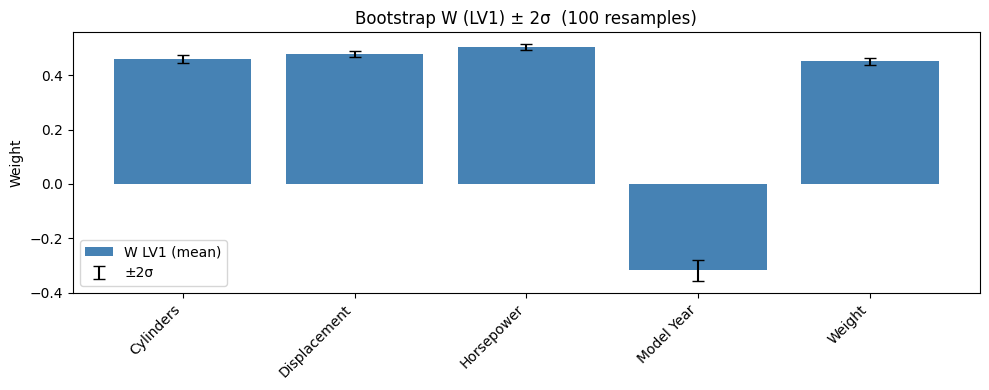

In [3]:
# Extract W (X-weights) from each bootstrap model and compute mean +/- 2*std
var_names = features.columns[1:].tolist()
n_vars = len(var_names)

# Stack W matrices: shape (n_boots, n_vars, n_latents)
W_stack = np.array([m['W'] for m in boot])   # (100, n_vars, 3)
W_mean = W_stack.mean(axis=0)                 # (n_vars, 3)
W_std  = W_stack.std(axis=0, ddof=1)          # (n_vars, 3)

print(f'W_mean shape: {W_mean.shape}')

# Plot LV1 weights with 2-sigma error bars
fig, ax = plt.subplots(figsize=(10, 4))
x_pos = np.arange(n_vars)
ax.bar(x_pos, W_mean[:, 0], color='steelblue', label='W LV1 (mean)')
ax.errorbar(x_pos, W_mean[:, 0], yerr=2*W_std[:, 0],
            fmt='none', color='black', capsize=4, label='±2σ')
ax.set_xticks(x_pos)
ax.set_xticklabels(var_names, rotation=45, ha='right')
ax.set_title('Bootstrap W (LV1) ± 2σ  (100 resamples)')
ax.set_ylabel('Weight')
ax.legend()
plt.tight_layout()
plt.show()


In [4]:
# Summary table: mean and std for all three LVs
import pandas as pd
rows = []
for j, vname in enumerate(var_names):
    rows.append({
        'Variable': vname,
        'W_LV1_mean': W_mean[j, 0], 'W_LV1_std': W_std[j, 0],
        'W_LV2_mean': W_mean[j, 1], 'W_LV2_std': W_std[j, 1],
        'W_LV3_mean': W_mean[j, 2], 'W_LV3_std': W_std[j, 2],
    })
summary = pd.DataFrame(rows).set_index('Variable')
summary.round(4)


,W_LV1_mean,W_LV1_std,W_LV2_mean,W_LV2_std,W_LV3_mean,W_LV3_std
Variable,,,,,,
Cylinders,0.4594,0.0069,-0.0610,0.1204,-0.1161,0.2095
Displacement,0.4788,0.0050,-0.0151,0.0863,-0.0902,0.1651
Horsepower,0.5040,0.0053,0.1902,0.6847,0.0689,0.2436
Model Year,-0.3176,0.0198,-0.0590,0.3889,-0.4456,0.7186
Weight,0.4519,0.0063,-0.1694,0.5432,-0.1758,0.3238


### Bootstrap Prediction Intervals

`phi.bootstrap_pls_pred(X_new, boot_list)` predicts Y for new observations and returns quantile bounds.

In [5]:
# Fit a reference PLS model on the full dataset for comparison
plsobj = phi.pls(features, performance, 3)
pred = phi.pls_pred(features, plsobj)
print('PLS Yhat shape:', pred['Yhat'].shape)

# Bootstrap prediction intervals at 2.5% / 97.5%
q025, q975 = phi.bootstrap_pls_pred(features, boot, quantiles=[0.025, 0.975])
print('q025 (mean Y across obs at 2.5%ile across boot models):', q025)
print('q975 (mean Y across obs at 97.5%ile across boot models):', q975)


phi.pls using NIPALS executed on: 2026-03-27 00:16:36.331195
# Iterations for LV #1:  5
# Iterations for LV #2:  30
# Iterations for LV #3:  7
--------------------------------------------------------------
LV #     Eig       R2X       sum(R2X)   R2Y       sum(R2Y)
LV #1:    3.850    0.776     0.776      0.541     0.541
LV #2:    0.143    0.042     0.818      0.136     0.677
LV #3:    0.750    0.151     0.969      0.023     0.700
--------------------------------------------------------------
PLS Yhat shape: (406, 2)


q025 (mean Y across obs at 2.5%ile across boot models): [15.37960534 23.19208567]
q975 (mean Y across obs at 97.5%ile across boot models): [15.78239711 23.86026568]


## Polynomial Regression with PLS Variable Selection

`build_polynomial(data, factors, response)` selects terms via PLS cross-validation and fits OLS on the selected subset. Returns `(betas, factors_out, X_aug, Y_vec, equation_string)`.

> **Note:** The returned `X_aug` includes a bias (intercept) column appended on the right, so `X_aug @ betas` gives the full prediction.

In [6]:
ex_data = pd.read_excel('../data/polynomial_data.xlsx')
print('Columns:', ex_data.columns.tolist())
print('Shape:', ex_data.shape)


Columns: ['Variable 1', 'Variable A', 'Var B', 'VarC', 'My Variable Name 2', 'Response 1']
Shape: (21, 6)


Built X from factors
phi.pls using NIPALS executed on: 2026-03-27 00:16:41.662024
# Iterations for LV #1:  1
# Iterations for LV #2:  1
# Iterations for LV #3:  1
# Iterations for LV #4:  1
# Iterations for LV #5:  1
# Iterations for LV #6:  1
--------------------------------------------------------------
LV #     Eig       R2X       sum(R2X)   R2Y       sum(R2Y)
LV #1:    3.195    0.574     0.574      0.897     0.897
LV #2:    1.344    0.269     0.843      0.055     0.952
LV #3:    0.360    0.094     0.937      0.030     0.982
LV #4:    0.317    0.056     0.993      0.017     0.999
LV #5:    0.026    0.005     0.998      0.001     1.000
LV #6:    0.013    0.002     1.000      0.000     1.000
--------------------------------------------------------------
Factors in model (incl. bias): ['Variable A', 'Var B', 'VarC', 'Variable A*VarC', 'Var B^2', 'Variable A^2*VarC', 'Bias']
Equation: 0.9872431787140984 * Variable A + 1.3090435673257166 * Var B + 1.2176705453343004 * VarC-0.002694159285

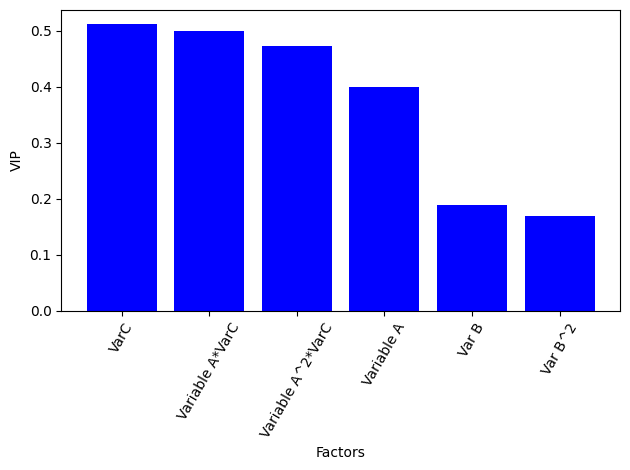

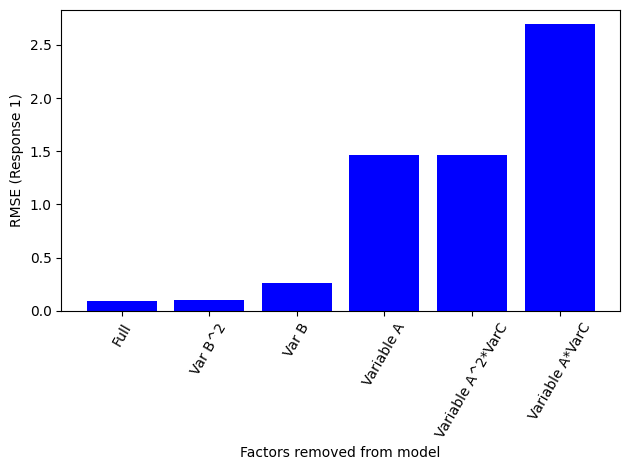

In [7]:
factors = [
    'Variable A', 'Var B', 'VarC',
    'Variable A*VarC', 'Var B^2', 'Variable A^2*VarC'
]
betas, selected, X_mat, Y_vec, eq_str = phi.build_polynomial(ex_data, factors, 'Response 1')
print('Factors in model (incl. bias):', selected)
print('Equation:', eq_str)


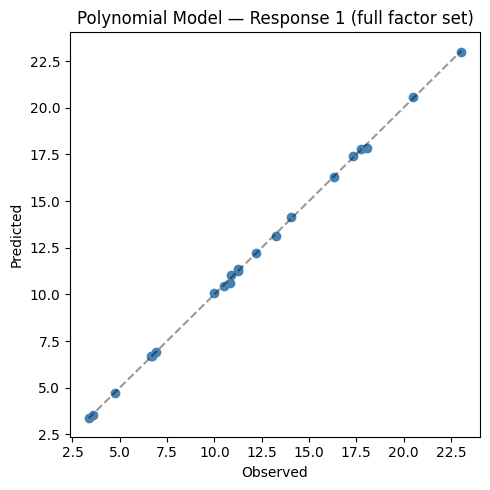

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(Y_vec, X_mat @ betas, 'o', color='steelblue')
ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')
ax.set_title('Polynomial Model — Response 1 (full factor set)')
lims = [min(float(Y_vec.min()), float((X_mat @ betas).min())),
        max(float(Y_vec.max()), float((X_mat @ betas).max()))]
ax.plot(lims, lims, 'k--', alpha=0.4)
plt.tight_layout()
plt.show()


## Reduced Model (fewer terms)

Built X from factors
phi.pls using NIPALS executed on: 2026-03-27 00:16:41.977048
# Iterations for LV #1:  1
# Iterations for LV #2:  1
# Iterations for LV #3:  1
# Iterations for LV #4:  1
--------------------------------------------------------------
LV #     Eig       R2X       sum(R2X)   R2Y       sum(R2Y)
LV #1:    2.940    0.778     0.778      0.925     0.925
LV #2:    0.494    0.166     0.943      0.042     0.967
LV #3:    0.201    0.053     0.996      0.029     0.996
LV #4:    0.014    0.004     1.000      0.002     0.998
--------------------------------------------------------------
Selected factors: ['Variable A', 'VarC', 'Variable A*VarC', 'Variable A^2*VarC', 'Bias']
Equation: 1.0302165510238597 * Variable A + 1.271952569905629 * VarC-0.02723187820604983 * Variable A*VarC + 0.0023650676485955646 * Variable A^2*VarC + 0.4680430162947795


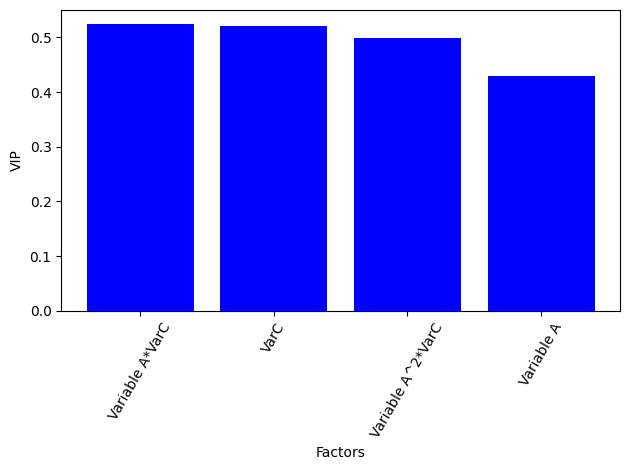

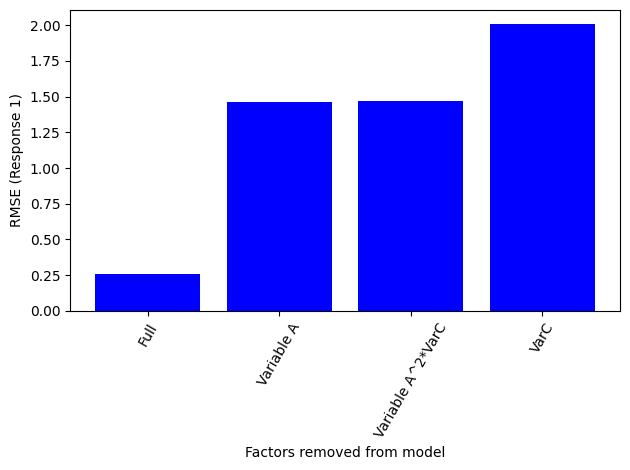

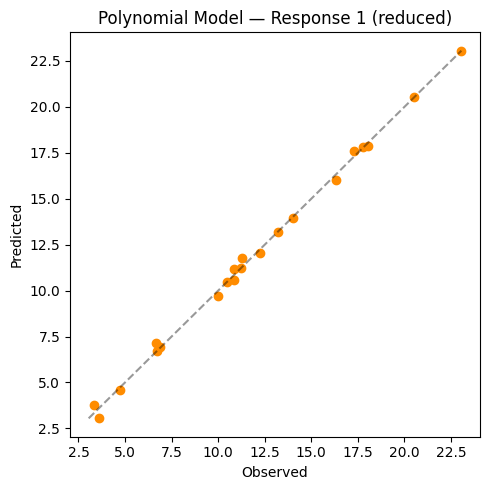

In [9]:
factors_reduced = ['Variable A', 'VarC', 'Variable A*VarC', 'Variable A^2*VarC']
betas2, selected2, X2, Y2, eq2 = phi.build_polynomial(ex_data, factors_reduced, 'Response 1')
print('Selected factors:', selected2)
print('Equation:', eq2)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(Y2, X2 @ betas2, 'o', color='darkorange')
ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')
ax.set_title('Polynomial Model — Response 1 (reduced)')
lims = [min(float(Y2.min()), float((X2 @ betas2).min())),
        max(float(Y2.max()), float((X2 @ betas2).max()))]
ax.plot(lims, lims, 'k--', alpha=0.4)
plt.tight_layout()
plt.show()
